# 01 — Метод 5: кластеризация пивотов в зоны («как рисует трейдер»)

В nb00 на картинке k=10 было видно: одиночный пивот слаб, а когда несколько пивотов
ложатся на одну цену — это и есть **уровень**. Здесь склеиваем близкие по цене
подтверждённые пивоты в зоны. Сила зоны = число пивотов (касаний).

**Причинность:** пивоты берём подтверждённые (k=10, лаг). Полярность не фиксируем —
пулим хаи и лоу вместе (старое сопротивление часто становится поддержкой).

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *

SYM = "ETHUSDT"
df = ohlcv(SYM, "2024-09-15", "2024-11-01", tf="1h")

def pivots(df, k):
    h = df["high"].to_numpy(); l = df["low"].to_numpy(); n = len(df)
    is_hi = np.zeros(n, bool); is_lo = np.zeros(n, bool)
    for i in range(k, n - k):
        wH = h[i - k:i + k + 1]; wL = l[i - k:i + k + 1]
        if h[i] == wH.max() and (wH == h[i]).sum() == 1: is_hi[i] = True
        if l[i] == wL.min() and (wL == l[i]).sum() == 1: is_lo[i] = True
    return is_hi, is_lo

def pivot_prices(df, k):
    hi, lo = pivots(df, k)
    return np.sort(np.concatenate([df["high"].to_numpy()[hi], df["low"].to_numpy()[lo]]))

def cluster_levels(prices, tol=0.006, min_touches=2):
    """1D clustering, ANCHOR-bounded: a pivot joins the current zone only if it is
    within tol of the zone ANCHOR (its min), so each zone is <= tol wide. (Chaining
    by nearest-neighbour gap instead lets zones drift arbitrarily wide — a bug.)"""
    p = np.sort(prices); clusters = [[p[0]]]
    for x in p[1:]:
        if (x - clusters[-1][0]) / clusters[-1][0] <= tol: clusters[-1].append(x)
        else: clusters.append([x])
    return [dict(lvl=float(np.mean(c)), lo=float(min(c)), hi=float(max(c)), n=len(c))
            for c in clusters if len(c) >= min_touches]

pp = pivot_prices(df, k=10)
zones = cluster_levels(pp, tol=0.006, min_touches=3)
print(f"{len(pp)} confirmed pivots → {len(zones)} zones (tol=0.6%, min_touches=3)")
for z in sorted(zones, key=lambda z: -z["n"]):
    print(f"  level {z['lvl']:7.1f}  band [{z['lo']:.0f},{z['hi']:.0f}]  width={100*(z['hi']-z['lo'])/z['lvl']:.2f}%  touches={z['n']}")

78 confirmed pivots → 14 zones (tol=0.6%, min_touches=3)
  level  2651.9  band [2647,2659]  width=0.44%  touches=7
  level  2567.7  band [2560,2574]  width=0.51%  touches=6
  level  2631.8  band [2628,2635]  width=0.27%  touches=5
  level  2671.2  band [2666,2676]  width=0.39%  touches=5
  level  2387.6  band [2381,2393]  width=0.51%  touches=4
  level  2440.2  band [2435,2444]  width=0.37%  touches=4
  level  2471.5  band [2470,2473]  width=0.11%  touches=4
  level  2510.0  band [2505,2514]  width=0.36%  touches=4
  level  2526.6  band [2521,2535]  width=0.57%  touches=4
  level  2591.8  band [2587,2600]  width=0.50%  touches=4
  level  2609.4  band [2605,2614]  width=0.32%  touches=4
  level  2685.5  band [2683,2689]  width=0.23%  touches=4
  level  2403.8  band [2398,2412]  width=0.55%  touches=3
  level  2458.8  band [2452,2463]  width=0.45%  touches=3


[saved] notebooks\levels\_out\01_pivot_clusters.png


WindowsPath('C:/projects/researchlab/notebooks/levels/_out/01_pivot_clusters.png')

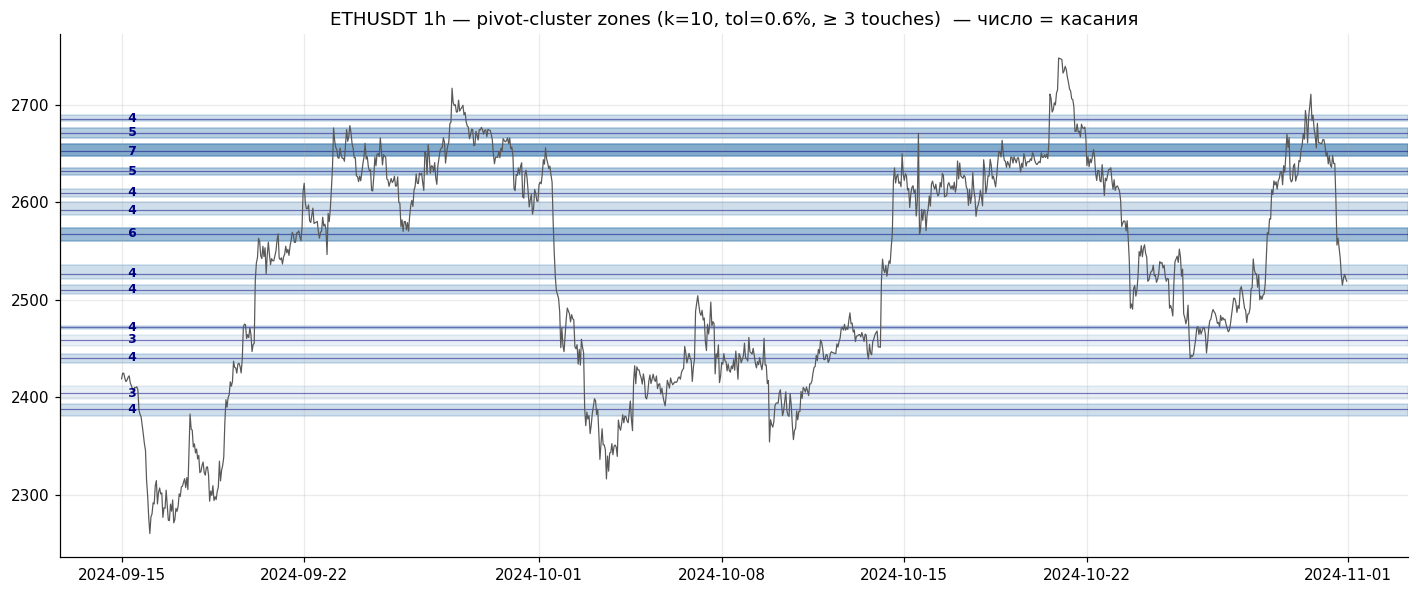

In [2]:
t = df.index
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(t, df["close"], lw=0.8, color="0.35", zorder=3)
nmax = max(z["n"] for z in zones)
for z in zones:
    a = 0.12 + 0.55 * (z["n"] - 3) / max(1, nmax - 3)  # stronger zone = more opaque
    ax.axhspan(z["lo"], z["hi"], color="steelblue", alpha=a, zorder=1)
    ax.axhline(z["lvl"], color="navy", lw=0.8, alpha=0.5, zorder=2)
    ax.text(t[2], z["lvl"], f" {z['n']}", va="center", fontsize=8, color="navy", fontweight="bold")
ax.set_title(f"{SYM} 1h \u2014 pivot-cluster zones (k=10, tol=0.6%, \u2265 3 touches)  \u2014 \u0447\u0438\u0441\u043b\u043e = \u043a\u0430\u0441\u0430\u043d\u0438\u044f")
show("01_pivot_clusters")

## Чувствительность к ручкам

Два knob'а определяют всё: `tol` (насколько близко склеивать) и `min_touches`
(сколько пивотов делают зону «настоящей»). Смотрим, сколько зон получается.

In [3]:
rows = []
for tol in (0.004, 0.006, 0.010):
    for mt in (2, 3, 4):
        z = cluster_levels(pp, tol=tol, min_touches=mt)
        rows.append({"tol": f"{tol:.1%}", "min_touches": mt, "n_zones": len(z),
                     "max_touches": max((x["n"] for x in z), default=0)})
import pandas as pd
pd.DataFrame(rows).pivot(index="tol", columns="min_touches", values="n_zones")

min_touches,2,3,4
tol,,,
0.4%,21,15,8
0.6%,20,14,12
1.0%,15,11,11


## Итог шага

Кластеризация сводит ~80 шумных пивотов к горсти зон, ранжированных по силе (касаниям).
Теперь в каталоге 5 причинных методов. Следующий шаг (nb 02) — единый количественный
тест всех пяти: плотность (доля времени «у уровня») + reaction-тест (forward-доходность
после касания vs baseline), пул по ~80 символам.